#### Problem Statement:
The dataset contains information such as job title, years of experience, education level, number of skills, industry, company size, location, remote-work status, and number of certifications. These factors can influence an individual's expected salary.

The goal is to analyze these factors, identify the variables that have the greatest impact on salary, and build a predictive model that can estimate the expected salary for a given job profile.

### Import all necessary libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
sns.set_theme(style='darkgrid', palette='viridis')
import plotly.express as pe 
import warnings
warnings.filterwarnings('ignore')

### Understand the dataset

In [2]:
df=pd.read_csv(r"job_salary_prediction_dataset.csv")
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [3]:
df.shape

(250000, 10)

In [4]:
df.dtypes


job_title           object
experience_years     int64
education_level     object
skills_count         int64
industry            object
company_size        object
location            object
remote_work         object
certifications       int64
salary               int64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [6]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


### EDA

In [7]:
df.isna().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.replace(['',' ','!','@','#','$','NaN','*','?'],np.nan,inplace=True)

In [10]:
df.isna().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

### Boxplot to check whether outlier is present or not?

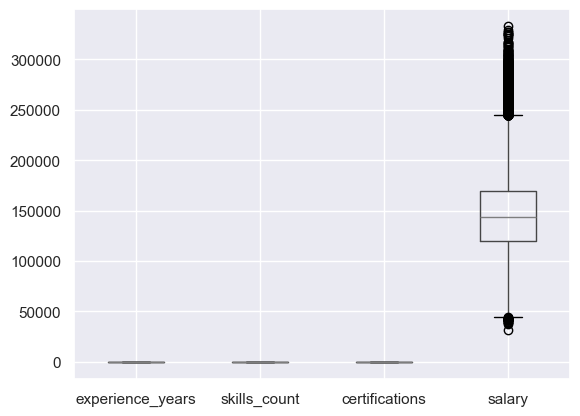

In [11]:
df.boxplot()
plt.show()

### Encoding

In [12]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [13]:
cols=['job_title','education_level','industry','company_size','location','remote_work']

In [14]:
for i in cols:
    print(f'\n Unique values in {i}')
    print(df[i].unique())


 Unique values in job_title
['AI Engineer' 'Data Analyst' 'Frontend Developer' 'Business Analyst'
 'Product Manager' 'Backend Developer' 'Machine Learning Engineer'
 'DevOps Engineer' 'Software Engineer' 'Cybersecurity Analyst'
 'Data Scientist' 'Cloud Engineer']

 Unique values in education_level
['Bachelor' 'PhD' 'High School' 'Diploma' 'Master']

 Unique values in industry
['Healthcare' 'Telecom' 'Media' 'Retail' 'Manufacturing' 'Education'
 'Finance' 'Technology' 'Consulting' 'Government']

 Unique values in company_size
['Medium' 'Small' 'Large' 'Enterprise' 'Startup']

 Unique values in location
['India' 'Australia' 'Singapore' 'Canada' 'Sweden' 'USA' 'Netherlands'
 'Remote' 'Germany' 'UK']

 Unique values in remote_work
['Hybrid' 'No' 'Yes']


### for job_title column we will do mapping

In [15]:
df.groupby('job_title')['salary'].mean().sort_values(ascending=False).reset_index()

,job_title,salary
0,AI Engineer,173498.480640
1,Machine Learning Engineer,163022.504570
2,Product Manager,157594.932029
3,Cloud Engineer,152102.535290
4,DevOps Engineer,149959.266791
5,Cybersecurity Analyst,148697.695548
6,Data Scientist,147258.214409
7,Software Engineer,141739.521460
8,Backend Developer,139202.768663
9,Frontend Developer,132653.842485


In [16]:
df['job_title']=df['job_title'].map({'Data Analyst':0, 'Business Analyst':1,'Frontend Developer':2,
                                    'Backend Developer':3,'Software Engineer':4,
                                     'Data Scientist':5,'Cybersecurity Analyst':6,
                                      'DevOps Engineer':7,'Cloud Engineer':8,
                                       'Product Manager':9,'Machine Learning Engineer':10,
                                        'AI Engineer':11 })

In [17]:
df['education_level']=df['education_level'].map({'High School':0,'Diploma':1,
                                                 'Bachelor':2,'Master':3,'PhD':4})

In [18]:
oe=OrdinalEncoder()
df['industry']=oe.fit_transform(df[['industry']])

In [19]:
df.groupby('company_size')['salary'].mean().sort_values(ascending=False).sort_index

<bound method Series.sort_index of company_size
Enterprise    169616.398957
Large         155711.112489
Medium        141537.535991
Small         134356.864298
Startup       127289.011974
Name: salary, dtype: float64>

In [20]:
df['company_size']=df['company_size'].map({'Startup':0,'Small':1,'Medium':2,'Large':3,'Enterprise':4})

In [21]:
df['location']=oe.fit_transform(df[['location']])

In [22]:
df['remote_work']=oe.fit_transform(df[['remote_work']])

In [23]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,11,10,2,2,4.0,2,3.0,0.0,2,109413
1,0,5,2,17,9.0,1,0.0,1.0,0,93764
2,2,18,4,4,6.0,2,6.0,1.0,1,148123
3,1,19,4,13,7.0,2,1.0,2.0,0,189123
4,9,15,2,7,5.0,3,7.0,2.0,0,165069


experience_years    0.437627
company_size        0.400253
job_title           0.392832
education_level     0.304823
location            0.178223
skills_count        0.127300
certifications      0.073819
remote_work         0.057829
industry            0.000713
Name: salary, dtype: float64


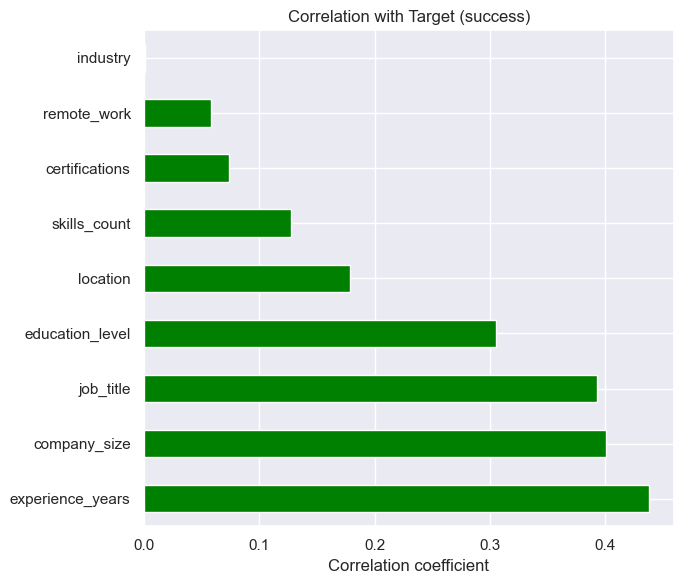

In [24]:
numeric_df = df.select_dtypes(include=[int,float])
target_corr = numeric_df.corr()['salary'].drop('salary').sort_values(key=abs, ascending=False)
print(target_corr)

plt.figure(figsize=(7,6))
target_corr.plot(kind='barh', color=['green' if v > 0 else 'red' for v in target_corr])
plt.title('Correlation with Target (success)')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

### Deleting the columns whose correlation is less with target column

In [25]:
df.drop(columns=['industry','remote_work'], inplace=True)

In [26]:
df.shape

(250000, 8)

### Define X and y

In [27]:
X=df.drop(columns=['salary'])
y=df['salary']

### Scaling

In [28]:
sc=StandardScaler()
X=sc.fit_transform(X)
X

array([[ 1.59341839e+00, -8.92322321e-04, -4.52631678e-04, ...,
        -1.56092564e-03, -5.20137814e-01, -2.88271936e-01],
       [-1.59671989e+00, -8.25894468e-01, -4.52631678e-04, ...,
        -7.09784901e-01, -1.56361343e+00, -1.46028059e+00],
       [-1.01669475e+00,  1.31911111e+00,  1.41402136e+00, ...,
        -1.56092564e-03,  5.23337806e-01, -8.74276261e-01],
       ...,
       [-1.30670732e+00, -1.48589618e+00, -4.52631678e-04, ...,
         1.41488702e+00, -5.20137814e-01, -1.46028059e+00],
       [-1.46657037e-01, -1.65089661e+00, -1.41492663e+00, ...,
        -7.09784901e-01,  8.71163013e-01,  1.46974104e+00],
       [-1.59671989e+00,  9.89110253e-01, -7.07689629e-01, ...,
        -1.56092564e-03,  1.21898822e+00,  1.46974104e+00]])

### Split dataset

In [29]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)

### Find out right KNN value

In [30]:
train_acc=[]
test_acc=[]
for i in range(2,20):
    knn=KNeighborsRegressor(n_neighbors=i)
    knn.fit(Xtrain,ytrain)
    train_acc.append(knn.score(Xtrain,ytrain))
    test_acc.append(knn.score(Xtest,ytest))

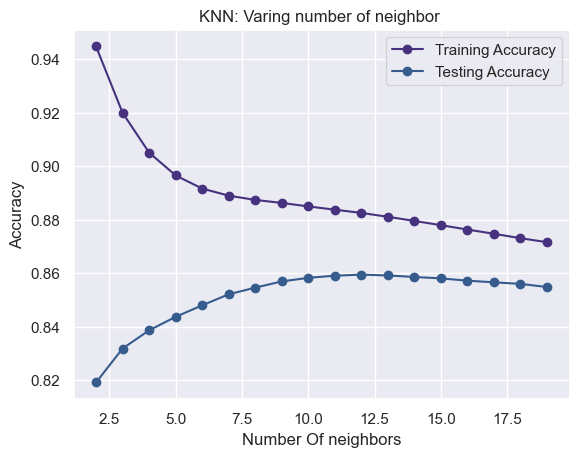

In [31]:
plt.plot(range(2,20),train_acc,label='Training Accuracy', marker='o')
plt.plot(range(2,20),test_acc,label='Testing Accuracy', marker='o')
plt.xlabel('Number Of neighbors')
plt.ylabel('Accuracy')
plt.title('KNN: Varing number of neighbor ')
plt.legend()
plt.show()


### Train the model with best KNN value

In [32]:
knn=KNeighborsRegressor(n_neighbors=9)
knn.fit(Xtrain,ytrain)
ypred=knn.predict(Xtest)
print(f"Training Accuracy : {knn.score(Xtrain, ytrain)}")
print(f"Test Accuracy : {knn.score(Xtest, ytest)}")



Training Accuracy : 0.8862858565310487
Test Accuracy : 0.8569443066856135


#### Conclusion:

### Conclusion

This project focused on predicting an individual's salary based on factors such as job title, years of experience, education level, number of skills, industry, company size, location, remote-work status, and certifications. The dataset contained 250,000 records and 10 variables, with no missing values or duplicate records.
Exploratory Data Analysis showed that **experience, company size, job title, and education level** have relatively stronger relationships with salary. Among the analyzed variables, experience had the highest correlation with salary (**0.438**), followed by company size (**0.400**), job title (**0.393**), and education level (**0.305**).

The categorical variables were converted into numerical form and the dataset was prepared for machine-learning modeling. The analysis of average salary by job title also showed noticeable salary differences across roles, with **AI Engineer having the highest average salary** and **Data Analyst having the lowest average salary** among the listed roles.

Overall, the project demonstrates how **data preprocessing, exploratory data analysis, feature encoding, correlation analysis, and KNN-based regression** can be used to build a salary prediction solution .
